# AzuaHousing.Example

This notebook is an **example consumer workflow**:

- Load the trained model artifact from `artifacts/model.joblib`
- Load metadata from `artifacts/metrics.json`
- Load the dataset
- Run inference and compute evaluation metrics on a held-out split
- Inspect prediction errors and visualize results

**Prerequisites**:
1) Run `AzuaHousing.API.ipynb` first (to generate `artifacts/`).
2) Ensure dependencies are installed via `requirements.txt`.


In [1]:
import os, json, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from azua_utils import load_melbourne, load_model

## Verify artifacts exist

This notebook expects artifacts created by the API notebook:
- `artifacts/model.joblib`
- `artifacts/metrics.json`


In [2]:
art_dir = Path("artifacts")
model_path = art_dir / "model.joblib"
meta_path = art_dir / "metrics.json"

print("model_path:", model_path, "exists:", model_path.exists())
print("meta_path :", meta_path, "exists:", meta_path.exists())

if not model_path.exists() or not meta_path.exists():
    raise FileNotFoundError(
        "Missing artifacts. Run AzuaHousing.API.ipynb first to create artifacts/model.joblib and artifacts/metrics.json."
    )

model_path: artifacts/model.joblib exists: True
meta_path : artifacts/metrics.json exists: True


## Load model + metadata

We load:
- the fitted sklearn `Pipeline` from `model.joblib`
- training metadata (best model name and CV scores) from `metrics.json`


In [3]:
model = load_model(str(model_path))
with open(meta_path, "r") as f:
    meta = json.load(f)

print("Saved model:", meta.get("model"))
print("Saved CV RMSE:", meta.get("rmse_cv"))
print("Saved CV R2:", meta.get("r2_cv"))
meta

Saved model: xgb
Saved CV RMSE: 273523.7317694481
Saved CV R2: 0.8148948822932052


{'model': 'xgb',
 'rmse_cv': 273523.7317694481,
 'r2_cv': 0.8148948822932052,
 'num_cols': ['Rooms',
  'Distance',
  'Postcode',
  'Bedroom2',
  'Bathroom',
  'Car',
  'Landsize',
  'BuildingArea',
  'YearBuilt',
  'Lattitude',
  'Longtitude',
  'Propertycount',
  'Year',
  'Month'],
 'cat_cols': ['Suburb',
  'Type',
  'Method',
  'SellerG',
  'CouncilArea',
  'Regionname'],
 'drop_cols': ['Address'],
 'folds': 5,
 'random_state': 42}

## Load data

We load the dataset from `DATA_PATH` (default: `data/melb_data.csv`) using the shared loader.


In [4]:
DATA_PATH = os.environ.get("DATA_PATH", "data/melb_data.csv")
print("DATA_PATH =", DATA_PATH)

df_raw = load_melbourne(DATA_PATH)
print("raw shape:", df_raw.shape)
df_raw.head()

DATA_PATH = data/melb_data.csv
raw shape: (13580, 22)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Distance,Postcode,Bedroom2,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Year,Month
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2.5,3067.0,2.0,...,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0,2016.0,3.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2.5,3067.0,2.0,...,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0,2016.0,4.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2.5,3067.0,3.0,...,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0,2017.0,4.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2.5,3067.0,3.0,...,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0,2017.0,4.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2.5,3067.0,3.0,...,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0,2016.0,4.0


## Compute stats (raw)

Basic dataset health checks and target distribution overview.


,value
rows,1.358000e+04
cols,2.200000e+01
duplicates,8.000000e+00
missing_cells,3.014000e+04
target_mean,1.075684e+06
target_std,6.393107e+05
target_min,8.500000e+04
target_max,9.000000e+06


,missing_%
Year,62.164948
Month,62.164948
BuildingArea,47.496318
YearBuilt,39.580265
CouncilArea,10.081001
Car,0.456554


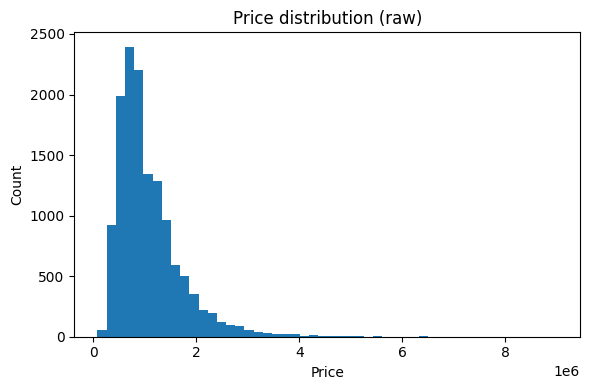

In [5]:
def compute_basic_stats(df: pd.DataFrame, target: str = "Price", top_missing: int = 12):
    stats = {
        "rows": int(df.shape[0]),
        "cols": int(df.shape[1]),
        "duplicates": int(df.duplicated().sum()),
        "missing_cells": int(df.isna().sum().sum()),
    }
    if target in df.columns:
        s = df[target].astype(float)
        stats.update({
            "target_mean": float(s.mean()),
            "target_std": float(s.std()),
            "target_min": float(s.min()),
            "target_max": float(s.max()),
        })
    missing = (df.isna().mean().sort_values(ascending=False) * 100.0)
    missing_tbl = missing[missing > 0].head(top_missing).to_frame("missing_%")
    return pd.Series(stats), missing_tbl

raw_stats, raw_missing = compute_basic_stats(df_raw, target="Price")
display(raw_stats.to_frame("value"))
display(raw_missing)

plt.figure(figsize=(6, 4))
plt.hist(df_raw["Price"].dropna().astype(float), bins=50)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price distribution (raw)")
plt.tight_layout()
plt.show()

## Clean data

We apply conservative cleaning similar to what you used in the API notebook:
- Drop duplicates
- Coerce common numeric columns
- Replace invalid negatives with NaN
- Sanity-check `YearBuilt`


In [6]:
def clean_melbourne_df(df: pd.DataFrame) -> pd.DataFrame:
    df2 = df.copy()
    df2 = df2.drop_duplicates()

    coerce_cols = ["Postcode", "Propertycount", "YearBuilt", "Car", "Bathroom", "Bedroom2", "Rooms",
                   "Distance", "Landsize", "BuildingArea", "Year", "Month"]
    for col in coerce_cols:
        if col in df2.columns:
            df2[col] = pd.to_numeric(df2[col], errors="coerce")

    nonneg_cols = ["Distance", "Landsize", "BuildingArea", "Car", "Bathroom", "Bedroom2", "Rooms"]
    for col in nonneg_cols:
        if col in df2.columns:
            df2.loc[df2[col] < 0, col] = np.nan

    if "YearBuilt" in df2.columns:
        year_now = pd.Timestamp.today().year
        df2.loc[(df2["YearBuilt"] < 1800) | (df2["YearBuilt"] > year_now + 1), "YearBuilt"] = np.nan

    # Keep only rows with target
    df2 = df2.dropna(subset=["Price"])
    return df2

df = clean_melbourne_df(df_raw)
print("clean shape:", df.shape)
df.head()

clean shape: (13572, 22)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Distance,Postcode,Bedroom2,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Year,Month
0,Abbotsford,85 Turner St,2.0,h,1480000.0,S,Biggin,2.5,3067.0,2.0,...,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0,2016.0,3.0
1,Abbotsford,25 Bloomburg St,2.0,h,1035000.0,S,Biggin,2.5,3067.0,2.0,...,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0,2016.0,4.0
2,Abbotsford,5 Charles St,3.0,h,1465000.0,SP,Biggin,2.5,3067.0,3.0,...,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0,2017.0,4.0
3,Abbotsford,40 Federation La,3.0,h,850000.0,PI,Biggin,2.5,3067.0,3.0,...,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0,2017.0,4.0
4,Abbotsford,55a Park St,4.0,h,1600000.0,VB,Nelson,2.5,3067.0,3.0,...,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0,2016.0,4.0


## Compute stats (cleaned)

We recompute the same stats after cleaning.


,value
rows,1.357200e+04
cols,2.200000e+01
duplicates,0.000000e+00
missing_cells,3.011900e+04
target_mean,1.075684e+06
target_std,6.394321e+05
target_min,8.500000e+04
target_max,9.000000e+06


,missing_%
Year,62.142647
Month,62.142647
BuildingArea,47.502210
YearBuilt,39.588859
CouncilArea,10.086944
Car,0.456823


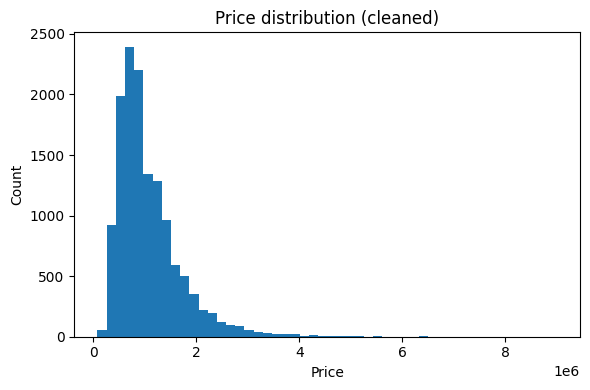

In [7]:
clean_stats, clean_missing = compute_basic_stats(df, target="Price")
display(clean_stats.to_frame("value"))
display(clean_missing)

plt.figure(figsize=(6, 4))
plt.hist(df["Price"].dropna().astype(float), bins=50)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price distribution (cleaned)")
plt.tight_layout()
plt.show()

## Inference + evaluation

We create a held-out split and evaluate the loaded model on the test set.


In [8]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print("train:", train_df.shape, "test:", test_df.shape)

X_test = test_df.drop(columns=["Price"], errors="ignore")
y_test = test_df["Price"].astype(float)

pred = model.predict(X_test)

rmse = math.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("Loaded model name (from metrics.json):", meta.get("model"))
print("TEST RMSE:", round(rmse, 2))
print("TEST MAE :", round(mae, 2))
print("TEST R2  :", round(r2, 4))

train: (10857, 22) test: (2715, 22)
Loaded model name (from metrics.json): xgb
TEST RMSE: 247235.91
TEST MAE : 148093.34
TEST R2  : 0.855


## Error analysis (best/worst cases)

We inspect predictions with the smallest and largest absolute errors.


In [9]:
eval_df = test_df.copy()
eval_df["y_true"] = y_test.values
eval_df["y_pred"] = pred
eval_df["abs_error"] = (eval_df["y_true"] - eval_df["y_pred"]).abs()

display(eval_df[["y_true", "y_pred", "abs_error"]].sort_values("abs_error").head(10))
display(eval_df[["y_true", "y_pred", "abs_error"]].sort_values("abs_error", ascending=False).head(10))


,y_true,y_pred,abs_error
12932,710000.0,7.099674e+05,32.56250
5758,1035000.0,1.035194e+06,194.12500
2792,1875000.0,1.875275e+06,275.00000
9269,945000.0,9.452928e+05,292.81250
3489,825000.0,8.253670e+05,367.00000
8962,765000.0,7.654160e+05,416.00000
10735,338000.0,3.375582e+05,441.75000
8412,990000.0,9.895086e+05,491.43750
2022,445000.0,4.455012e+05,501.15625
3099,1255000.0,1.255673e+06,673.37500


,y_true,y_pred,abs_error
9575,7650000.0,4257973.00,3392027.00
12557,6400000.0,3665936.75,2734063.25
3616,6500000.0,4223236.00,2276764.00
9233,5600000.0,3405537.50,2194462.50
4791,3705000.0,2008768.25,1696231.75
12691,2950000.0,1364832.00,1585168.00
4980,760000.0,2284626.00,1524626.00
5556,770000.0,2202226.75,1432226.75
12219,5100000.0,3727583.25,1372416.75
533,390000.0,1749479.75,1359479.75


## Visualize results

- Predicted vs actual scatter
- Residual histogram


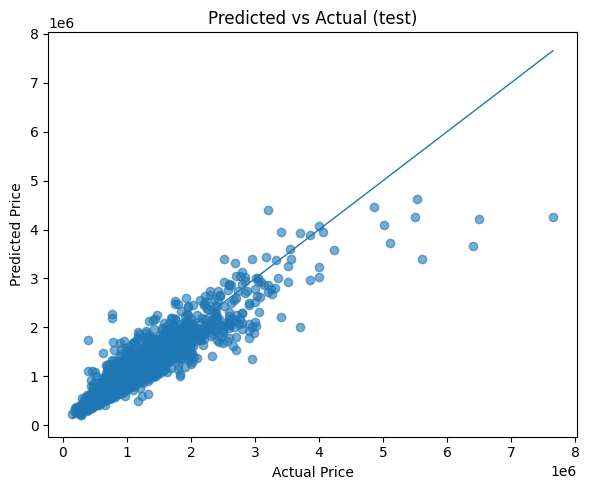

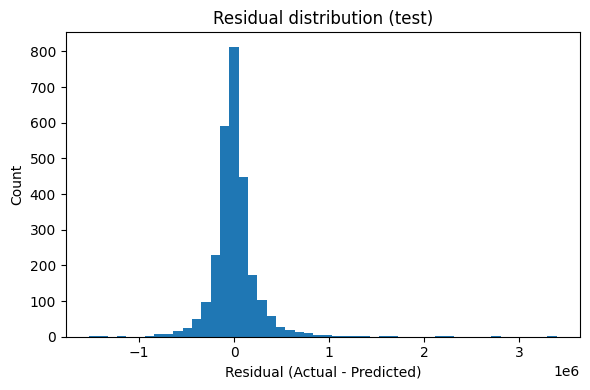

In [10]:
plt.figure(figsize=(6, 5))
plt.scatter(eval_df["y_true"], eval_df["y_pred"], alpha=0.6)
mn = float(min(eval_df["y_true"].min(), eval_df["y_pred"].min()))
mx = float(max(eval_df["y_true"].max(), eval_df["y_pred"].max()))
plt.plot([mn, mx], [mn, mx], linewidth=1)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual (test)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
residuals = (eval_df["y_true"] - eval_df["y_pred"]).astype(float)
plt.hist(residuals, bins=50)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Residual distribution (test)")
plt.tight_layout()
plt.show()

## Save a prediction sample

We write a small CSV under `artifacts/` for debugging/reporting.


In [11]:
out_path = Path("artifacts") / "predictions_sample.csv"
cols_to_save = ["y_true", "y_pred", "abs_error"]
eval_df[cols_to_save].to_csv(out_path, index=False)
print("Wrote:", out_path, "rows:", len(eval_df))

Wrote: artifacts/predictions_sample.csv rows: 2715


## Single-row prediction example

This shows how to score a single input row (as a dataframe with one row).


In [12]:
one_x = X_test.iloc[[0]].copy()
one_pred = float(model.predict(one_x)[0])
print("Single example predicted price:", one_pred)
one_x

Single example predicted price: 1333871.75


,Suburb,Address,Rooms,Type,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Year,Month
749,Bentleigh,64 Tucker Rd,3.0,h,S,Buxton,13.0,3204.0,3.0,2.0,...,581.0,170.0,1965.0,Glen Eira,-37.9286,145.0495,Southern Metropolitan,6795.0,NaN,NaN


## Interactive prediction (user input → model prediction)

This section provides an interactive form to input feature values and get a predicted house price from the saved model pipeline.


In [13]:
import numpy as np
import pandas as pd

# Determine which feature columns the trained pipeline expects
drop_cols = meta.get("drop_cols", []) if isinstance(meta, dict) else []
feature_cols = [c for c in df.columns if c != "Price" and c not in drop_cols]

# Prefer stored lists from training metadata (more stable)
num_cols_meta = set(meta.get("num_cols", [])) if isinstance(meta, dict) else set()
cat_cols_meta = set(meta.get("cat_cols", [])) if isinstance(meta, dict) else set()

# Fallback: infer if metadata missing
if not num_cols_meta and not cat_cols_meta:
    num_cols_meta = set(df[feature_cols].select_dtypes(include=[np.number]).columns.tolist())
    cat_cols_meta = set([c for c in feature_cols if c not in num_cols_meta])

print("Drop columns:", drop_cols)
print("Num features :", len(num_cols_meta))
print("Cat features :", len(cat_cols_meta))
print("Total features:", len(feature_cols))

Drop columns: ['Address']
Num features : 14
Cat features : 6
Total features: 20


In [14]:
# Fill only what you care about; the pipeline imputers can handle NaNs.

example_input = {
    # Categorical examples (strings)
    "Suburb": "Abbotsford",
    "Type": "h",
    "Method": "S",
    "SellerG": "Biggin",
    "CouncilArea": "Yarra",
    "Regionname": "Northern Metropolitan",

    # Numeric examples
    "Rooms": 2,
    "Distance": 2.5,
    "Postcode": 3067,
    "Bedroom2": np.nan,
    "Bathroom": np.nan,
    "Car": np.nan,
    "Landsize": 202,
    "BuildingArea": np.nan,
    "YearBuilt": np.nan,
    "Lattitude": -37.7996,
    "Longtitude": 144.9984,
    "Propertycount": 4019,
    "Year": 2016,
    "Month": 3,
}

# Build a one-row dataframe with the expected feature columns
X_one = pd.DataFrame([{c: example_input.get(c, np.nan) for c in feature_cols}], columns=feature_cols)
y_hat = float(model.predict(X_one)[0])

display(X_one)
print(f"Predicted Price: {y_hat:,.2f}")

,Suburb,Rooms,Type,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Year,Month
0,Abbotsford,2,h,S,Biggin,2.5,3067,NaN,NaN,NaN,202,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019,2016,3


Predicted Price: 1,107,810.88
